Device: cpu


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generator: a cat sitting on a couch with a pink pillow
Verifier : a cat sits on a couch
Similarity: 0.817
Fault: False
------
Generator: a man standing in a field of tall grass
Verifier : the back view of a man looking at a field of tall grass in front of a distant mountain range
Similarity: 0.666
Fault: True
------
Generator: a white desk with a computer on it
Verifier : wooden desk for works
Similarity: 0.632
Fault: True
------
Generator: a living room with a couch and a table
Verifier : this is a living room
Similarity: 0.711
Fault: False
------
Generator: a black pug dog wearing a scarf
Verifier : a pug looking over a phone on a yellow background
Similarity: 0.441
Fault: True
------
Mean: 0.653
Std: 0.123
Min: 0.441
Max: 0.817


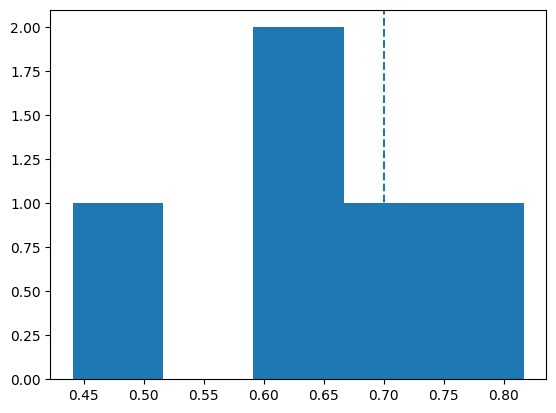

In [2]:
!pip install transformers sentence-transformers matplotlib

import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

from transformers import BlipProcessor, BlipForConditionalGeneration
from sentence_transformers import SentenceTransformer, util

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

sbert = SentenceTransformer('all-MiniLM-L6-v2')

image_urls = [
    "https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
    "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d",
    "https://images.unsplash.com/photo-1492724441997-5dc865305da7",
    "https://images.unsplash.com/photo-1507149833265-60c372daea22",
    "https://images.unsplash.com/photo-1517849845537-4d257902454a"
]

def load_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert('RGB')

def generate_caption(image):
    inputs = blip_processor(image, return_tensors="pt").to(device)
    out = blip_model.generate(**inputs, max_new_tokens=20)
    return blip_processor.decode(out[0], skip_special_tokens=True)

def generate_verifier_caption(image):
    inputs = blip_processor(image, return_tensors="pt").to(device)
    out = blip_model.generate(
        **inputs,
        do_sample=True,
        temperature=1.0,
        top_p=0.9,
        max_new_tokens=20
    )
    return blip_processor.decode(out[0], skip_special_tokens=True)

def compute_similarity(c1, c2):
    emb1 = sbert.encode(c1, convert_to_tensor=True)
    emb2 = sbert.encode(c2, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

threshold = 0.7
results = []

for url in image_urls:
    image = load_image(url)

    cg = generate_caption(image)
    cv = generate_verifier_caption(image)

    sim = compute_similarity(cg, cv)
    fault = sim < threshold

    results.append(sim)

    print("Generator:", cg)
    print("Verifier :", cv)
    print("Similarity:", round(sim, 3))
    print("Fault:", fault)
    print("------")

results = np.array(results)

print("Mean:", round(results.mean(), 3))
print("Std:", round(results.std(), 3))
print("Min:", round(results.min(), 3))
print("Max:", round(results.max(), 3))

plt.hist(results, bins=5)
plt.axvline(x=threshold, linestyle='--')
plt.show()